In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import gymnasium as gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import rl_utils

Define policy net

In [2]:
class PolicyNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(PolicyNet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,action_dim)
    
    def forward(self,x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x),dim=1)
    

Define value net

In [3]:
class ValueNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim):
        super(ValueNet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.relu = torch.nn.ReLU()
        self.fc2 = torch.nn.Linear(hidden_dim,1)
    
    def forward(self,x):
        x = self.relu(self.fc1(x))
        return self.fc2(x)

Define ActorCritc algorithm

In [4]:
class ActorCritic:
    def __init__(self,state_dim,hidden_dim,action_dim,actor_lr,
                 critic_lr,gamma,device):
        self.actor = PolicyNet(state_dim,hidden_dim,action_dim).to(device)
        self.critic = ValueNet(state_dim,hidden_dim).to(device)
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),
                                                lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(),
                                                 lr=critic_lr)
        self.gamma = gamma
        self.device = device

    def take_action(self,state):
        # Wrap it with np.array , and add unsqueeze to increase the batch dimension.
        state = torch.tensor(np.array(state), dtype=torch.float32).unsqueeze(0).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self,transition_dict):
        states = torch.tensor(np.array(transition_dict['states']), dtype=torch.float32).to(self.device)
        actions = torch.tensor(np.array(transition_dict['actions']), dtype=torch.int64).view(-1, 1).to(self.device)
        rewards = torch.tensor(np.array(transition_dict['rewards']), dtype=torch.float32).view(-1, 1).to(self.device)
        next_states = torch.tensor(np.array(transition_dict['next_states']), dtype=torch.float32).to(self.device)
        dones = torch.tensor(np.array(transition_dict['dones']), dtype=torch.float32).view(-1, 1).to(self.device)

        td_target = rewards + self.gamma * self.critic(next_states)*(1-dones)
        td_delta = td_target - self.critic(states)
        log_probs = torch.log(self.actor(states).gather(1,actions))
        actor_loss = torch.mean(-log_probs * td_delta.detach())
        critic_loss = torch.mean(F.mse_loss(self.critic(states),td_target.detach()))
        self.actor_optimizer.zero_grad()
        self.critic_optimizer.zero_grad()
        actor_loss.backward()  
        critic_loss.backward() 
        self.actor_optimizer.step()  
        self.critic_optimizer.step()  

        

In [5]:
actor_lr = 1.5e-3
critic_lr = 1.5e-2
num_episodes = 2000
hidden_dim = 128
gamma = 0.98
if(torch.cuda.is_available()):
    device = 'cuda'
elif(torch.backends.mps.is_available()):
    device = 'mps'
else:
    device = 'cpu'

env_name = 'CartPole-v1'
env = gym.make(env_name)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = ActorCritic(state_dim, hidden_dim, action_dim, actor_lr, critic_lr,
                    gamma, device)

return_list = rl_utils.train_on_policy_agent(env, agent, num_episodes)

Iteration 9: 100%|██████████| 200/200 [00:05<00:00, 35.12it/s, episode=2000, return=500.000]


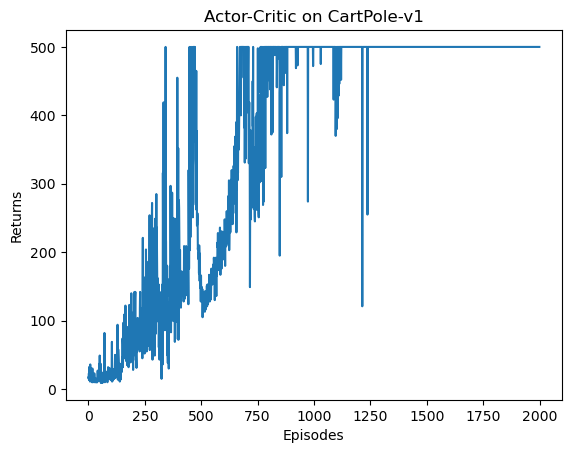

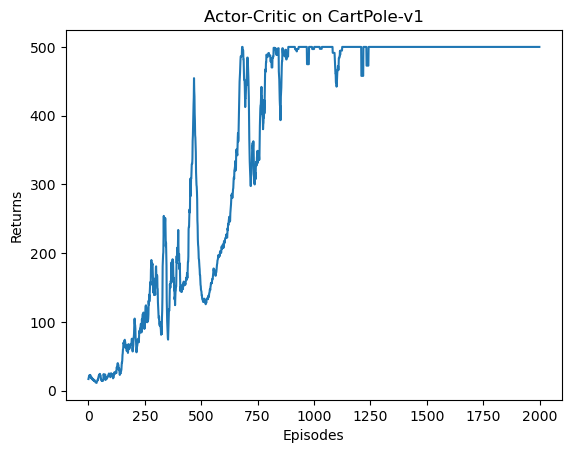

In [6]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor-Critic on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor-Critic on {}'.format(env_name))
plt.show()

stablized at 500, showing the algorithm get the best solution for cartpole